In [1]:
import pandas as pd
import numpy as np
import os
from IPython.display import display
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


In [2]:
import numpy as np
from pathlib import Path

def incarca_npy_ca_variabile(folder_path):
    folder = Path(folder_path)
    
    for file_path in folder.glob('*.npy'):
        # Luăm numele fișierului fără ".npy"
        nume_baza = file_path.stem 
        
        # 1. Înlocuim cratimele și spațiile cu underscore (_) ca să fie valid în Python
        nume_variabila = nume_baza.replace('-', '_').replace(' ', '_')
        
        # 2. Dacă numele începe cu o cifră (ex: 2026...), îi punem un "v_" în față
        if nume_variabila[0].isdigit():
            nume_variabila = f"v_{nume_variabila}"
            
        # 3. Creăm variabila direct în mediul global!
        globals()[nume_variabila] = np.load(file_path)
        
        print(f"Gata! Am creat variabila: {nume_variabila}")

# --- CUM O FOLOSEȘTI ---
incarca_npy_ca_variabile('/Users/adaciortan/Desktop/experiment data/daca ai fii un stick/the column')

# DUPĂ CE RULEZI FUNCȚIA, POȚI SCRIE DIRECT:
# print(v_2026_02_25_h2_400bar_SRB_volume_1)

Gata! Am creat variabila: v_2026_02_25_h2_400bar_SRB_volume_1
Gata! Am creat variabila: v_2026_02_25_h2_400bar_SRB_time
Gata! Am creat variabila: v_2025_07_01_h2_100bar_SRB_volume_1
Gata! Am creat variabila: v_2026_02_25_h2_400bar_SRB_volume_2
Gata! Am creat variabila: v_2025_07_01_h2_100bar_SRB_volume_2
Gata! Am creat variabila: v_2026_02_10_h2_200bar_SRB_volume_2
Gata! Am creat variabila: v_2026_02_10_h2_200bar_SRB_volume_1
Gata! Am creat variabila: v_2026_02_10_h2_200bar_SRB_time
Gata! Am creat variabila: v_2025_07_01_h2_100bar_SRB_time
Gata! Am creat variabila: v_2025_10_23_h2_60bar_SRB_volume_2
Gata! Am creat variabila: v_2025_10_23_h2_60bar_SRB_volume_1
Gata! Am creat variabila: v_2025_06_18_h2_100bar_SRB_volume_2
Gata! Am creat variabila: v_2026_01_29_h2_400bar_SRB_volume_1
Gata! Am creat variabila: v_2026_01_29_h2_400bar_SRB_volume_2
Gata! Am creat variabila: v_2025_06_18_h2_100bar_SRB_volume_1
Gata! Am creat variabila: v_2025_11_11_h2_200bar_SRB_volume_2
Gata! Am creat variabi

In [3]:
import numpy as np

def trim_and_normalize_set(time_arr, vol1_arr, vol2_arr):
    """
    Sincronizează și normalizează un set de 3 array-uri bazat pe minimul din Volum 1.
    """
    # 1. Găsim indexul valorii minime din Volum 1
    min_idx = np.argmin(vol1_arr)
    
    # 2. Tăiem toate cele 3 array-uri de la acel index până la final
    t_trim = time_arr[min_idx:]
    v1_trim = vol1_arr[min_idx:]
    v2_trim = vol2_arr[min_idx:]
    
    # 3. Scădem valoarea minimă din fiecare array tăiat ca să înceapă de la 0
    # Folosim np.min() pentru a ne asigura că cel mai mic punct devine exact 0.0
    t_norm = t_trim - np.min(t_trim)
    v1_norm = v1_trim - np.min(v1_trim)
    v2_norm = v2_trim - np.min(v2_trim)
    
    return t_norm, v1_norm, v2_norm


In [4]:


# 1. Experiment 25 Feb 2026 (400 bar)
#v_2026_02_25_h2_400bar_SRB_time=v_2026_02_25_h2_400bar_SRB_time*24*60
time_26_02_25_clean, vol1_26_02_25_clean, vol2_26_02_25_clean = trim_and_normalize_set(
    v_2026_02_25_h2_400bar_SRB_time, 
    v_2026_02_25_h2_400bar_SRB_volume_1, 
    v_2026_02_25_h2_400bar_SRB_volume_2
)

# 2. Experiment 01 Iul 2025 (100 bar)
time_25_07_01_clean, vol1_25_07_01_clean, vol2_25_07_01_clean = trim_and_normalize_set(
    v_2025_07_01_h2_100bar_SRB_time, 
    v_2025_07_01_h2_100bar_SRB_volume_1, 
    v_2025_07_01_h2_100bar_SRB_volume_2
)

# 3. Experiment 10 Feb 2026 (200 bar)
time_26_02_10_clean, vol1_26_02_10_clean, vol2_26_02_10_clean = trim_and_normalize_set(
    v_2026_02_10_h2_200bar_SRB_time, 
    v_2026_02_10_h2_200bar_SRB_volume_1, 
    v_2026_02_10_h2_200bar_SRB_volume_2
)

# 4. Experiment 23 Oct 2025 (60 bar)
time_25_10_23_clean, vol1_25_10_23_clean, vol2_25_10_23_clean = trim_and_normalize_set(
    v_2025_10_23_h2_60bar_SRB_time, 
    v_2025_10_23_h2_60bar_SRB_volume_1, 
    v_2025_10_23_h2_60bar_SRB_volume_2
)

# 5. Experiment 18 Iun 2025 (100 bar)
time_25_06_18_clean, vol1_25_06_18_clean, vol2_25_06_18_clean = trim_and_normalize_set(
    v_2025_06_18_h2_100bar_SRB_time, 
    v_2025_06_18_h2_100bar_SRB_volume_1, 
    v_2025_06_18_h2_100bar_SRB_volume_2
)

# 6. Experiment 29 Ian 2026 (400 bar)
v_2026_01_29_h2_400bar_SRB_time = v_2026_01_29_h2_400bar_SRB_time * 24 * 60
time_26_01_29_clean, vol1_26_01_29_clean, vol2_26_01_29_clean = trim_and_normalize_set(
    v_2026_01_29_h2_400bar_SRB_time, 
    v_2026_01_29_h2_400bar_SRB_volume_1, 
    v_2026_01_29_h2_400bar_SRB_volume_2
)

# 7. Experiment 11 Nov 2025 (200 bar)

v_2025_11_11_h2_200bar_SRB_time=np.arange(0, 18324)
time_25_11_11_clean, vol1_25_11_11_clean, vol2_25_11_11_clean = trim_and_normalize_set(
    v_2025_11_11_h2_200bar_SRB_time, 
    v_2025_11_11_h2_200bar_SRB_volume_1, 
    v_2025_11_11_h2_200bar_SRB_volume_2
)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def convert_ml_to_mmol(volume_array_ml, pressure_bar):
    """
    Transformă un array de volume din ml în mmol de H2,
    ținând cont de densitatea specifică presiunii.
    """
    molar_mass_h2 = 2.016 # Masa molară a H2 în g/mol (sau mg/mmol)
    
    if pressure_bar == 100:
        density = 7.392   # kg/m^3 (echivalent cu g/L)
    elif pressure_bar == 200:
        density = 14.030
    elif pressure_bar == 400:
        density = 25.743
    elif pressure_bar == 60:
        density = 4.534
    else:
        raise ValueError("Presiune necunoscută. Te rog alege 100, 200 sau 400.")
        
    # Calcul: (Volum * Densitate) / Masa Molară
    return volume_array_ml * (density / molar_mass_h2)

# --- Aplicăm conversia pe datele curate (ignorăm setul de 60 bar) ---

# 400 bar
mmol1_26_02_25 = convert_ml_to_mmol(vol1_26_02_25_clean, 400)
mmol2_26_02_25 = convert_ml_to_mmol(vol2_26_02_25_clean, 400)

mmol1_26_01_29 = convert_ml_to_mmol(vol1_26_01_29_clean, 400)
mmol2_26_01_29 = convert_ml_to_mmol(vol2_26_01_29_clean, 400)

# 200 bar
mmol1_26_02_10 = convert_ml_to_mmol(vol1_26_02_10_clean, 200)
mmol2_26_02_10 = convert_ml_to_mmol(vol2_26_02_10_clean, 200)

mmol1_25_11_11 = convert_ml_to_mmol(vol1_25_11_11_clean, 200)
mmol2_25_11_11 = convert_ml_to_mmol(vol2_25_11_11_clean, 200)

# 100 bar
mmol1_25_07_01 = convert_ml_to_mmol(vol1_25_07_01_clean, 100)
mmol2_25_07_01 = convert_ml_to_mmol(vol2_25_07_01_clean, 100)

mmol1_25_06_18 = convert_ml_to_mmol(vol1_25_06_18_clean, 100)
mmol2_25_06_18 = convert_ml_to_mmol(vol2_25_06_18_clean, 100)

mmol1=convert_ml_to_mmol(vol1_25_10_23_clean , 60)
mmol2=convert_ml_to_mmol(vol2_25_10_23_clean, 60)

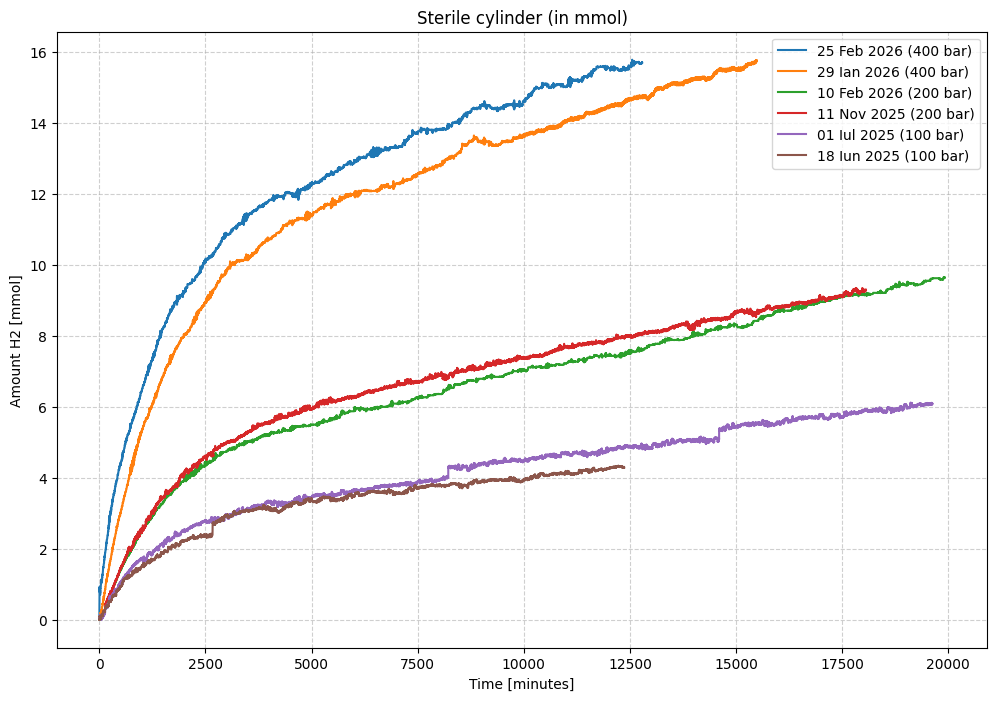

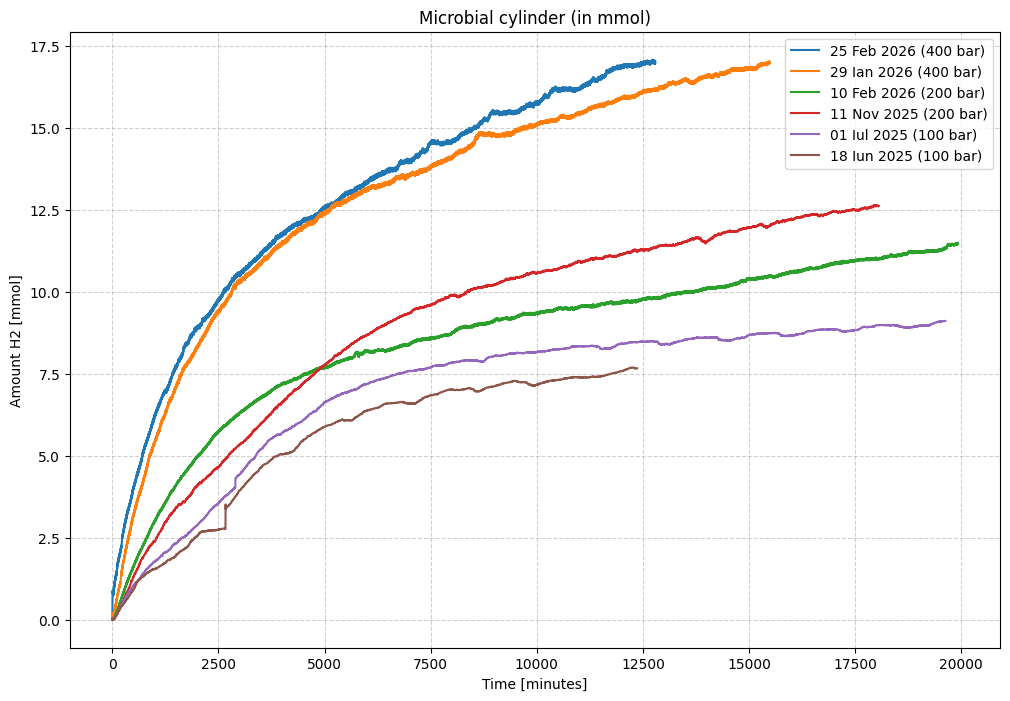

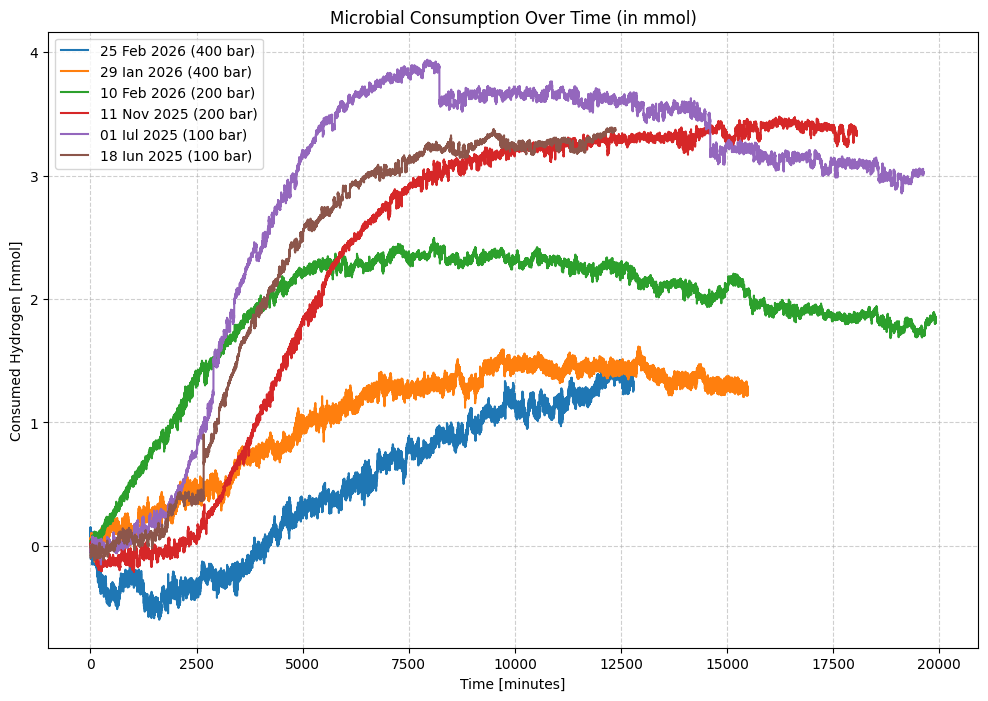

In [6]:
# ==========================================
# GRAFIC 1: Toate Channel 2 (în mmol) vs Timp
# ==========================================
plt.figure(figsize=(12, 8))

plt.plot(time_26_02_25_clean, mmol2_26_02_25, label="25 Feb 2026 (400 bar)", linewidth=1.5)
plt.plot(time_26_01_29_clean, mmol2_26_01_29, label="29 Ian 2026 (400 bar)", linewidth=1.5)
plt.plot(time_26_02_10_clean, mmol2_26_02_10, label="10 Feb 2026 (200 bar)", linewidth=1.5)
plt.plot(time_25_11_11_clean, mmol2_25_11_11, label="11 Nov 2025 (200 bar)", linewidth=1.5)
plt.plot(time_25_07_01_clean, mmol2_25_07_01, label="01 Iul 2025 (100 bar)", linewidth=1.5)
plt.plot(time_25_06_18_clean, mmol2_25_06_18, label="18 Iun 2025 (100 bar)", linewidth=1.5)

plt.xlabel("Time [minutes]")
plt.ylabel("Amount H2 [mmol]")
plt.title("Sterile cylinder (in mmol)")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# GRAFIC 2: Toate Channel 1 (în mmol) vs Timp
# ==========================================
plt.figure(figsize=(12, 8))

plt.plot(time_26_02_25_clean, mmol1_26_02_25, label="25 Feb 2026 (400 bar)", linewidth=1.5)
plt.plot(time_26_01_29_clean, mmol1_26_01_29, label="29 Ian 2026 (400 bar)", linewidth=1.5)
plt.plot(time_26_02_10_clean, mmol1_26_02_10, label="10 Feb 2026 (200 bar)", linewidth=1.5)
plt.plot(time_25_11_11_clean, mmol1_25_11_11, label="11 Nov 2025 (200 bar)", linewidth=1.5)
plt.plot(time_25_07_01_clean, mmol1_25_07_01, label="01 Iul 2025 (100 bar)", linewidth=1.5)
plt.plot(time_25_06_18_clean, mmol1_25_06_18, label="18 Iun 2025 (100 bar)", linewidth=1.5)

plt.xlabel("Time [minutes]")
plt.ylabel("Amount H2 [mmol]")
plt.title("Microbial cylinder (in mmol)")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==========================================
# GRAFIC 3: Consum Microbial (Channel 1 - Channel 2) în mmol
# ==========================================
plt.figure(figsize=(12, 8))

plt.plot(time_26_02_25_clean, mmol1_26_02_25 - mmol2_26_02_25, label="25 Feb 2026 (400 bar)", linewidth=1.5)
plt.plot(time_26_01_29_clean, mmol1_26_01_29 - mmol2_26_01_29, label="29 Ian 2026 (400 bar)", linewidth=1.5)
plt.plot(time_26_02_10_clean, mmol1_26_02_10 - mmol2_26_02_10, label="10 Feb 2026 (200 bar)", linewidth=1.5)
plt.plot(time_25_11_11_clean, mmol1_25_11_11 - mmol2_25_11_11, label="11 Nov 2025 (200 bar)", linewidth=1.5)
plt.plot(time_25_07_01_clean, mmol1_25_07_01 - mmol2_25_07_01, label="01 Iul 2025 (100 bar)", linewidth=1.5)
plt.plot(time_25_06_18_clean, mmol1_25_06_18 - mmol2_25_06_18, label="18 Iun 2025 (100 bar)", linewidth=1.5)

plt.xlabel("Time [minutes]")
plt.ylabel("Consumed Hydrogen [mmol]")
plt.title("Microbial Consumption Over Time (in mmol)")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


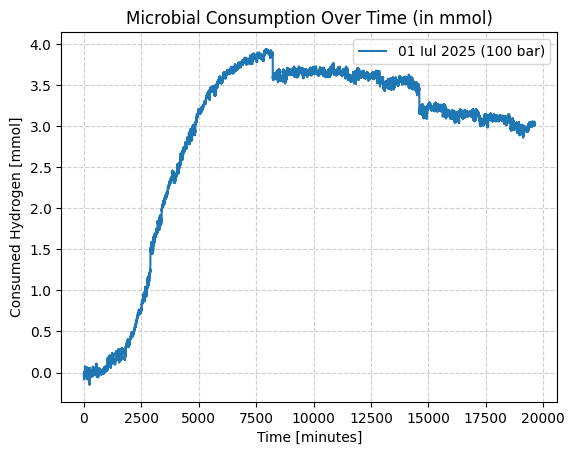

In [9]:
plt.plot(time_25_07_01_clean, mmol1_25_07_01 - mmol2_25_07_01, label="01 Iul 2025 (100 bar)", linewidth=1.5)
#plt.plot(time_25_06_18_clean, mmol1_25_06_18 - mmol2_25_06_18, label="18 Iun 2025 (100 bar)", linewidth=1.5)

plt.xlabel("Time [minutes]")
plt.ylabel("Consumed Hydrogen [mmol]")
plt.title("Microbial Consumption Over Time (in mmol)")
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


--- Fitted Biological Parameters ---
Initial Population (logN0): 0.168
Max Population (logNmax):   2.139
Max Growth Rate (μ_max):    1.036
Lag Time (λ):               0.502


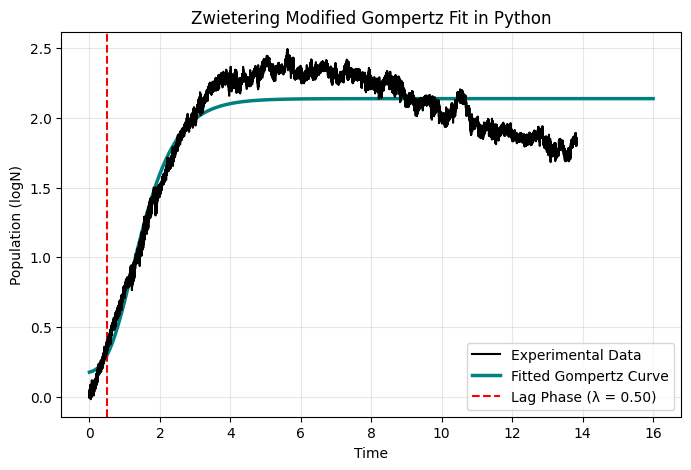

In [20]:
from scipy.optimize import curve_fit

# 1. Define the Zwietering Gompertz function for absolute log data
def zwietering_gompertz_abs(t, logN0, logNmax, mu_max, lmbda):
    """
    t: time
    logN0: initial log population
    logNmax: maximum log population
    mu_max: maximum specific growth rate
    lmbda: lag time
    """
    # A is the maximum log-increase in population
    A = logNmax - logN0 
    return logN0 + A * np.exp(-np.exp((mu_max * np.e / A) * (lmbda - t) + 1))

# 2. Experimental dataset (matching the R example)
time = time_26_02_10_clean /( 60*24)  # Convertim timpul în ore pentru o scală mai potrivită
logN = mmol1_26_02_10 - mmol2_26_02_10

# 3. Initial guesses for the algorithm [logN0, logNmax, mu_max, lambda]
initial_guesses = [0, 2.5, 1.9, 0]

# 4. Run the curve-fitting code
# popt contains the fitted parameters, pcov contains the covariance matrix
popt, pcov = curve_fit(zwietering_gompertz_abs, time, logN, p0=initial_guesses)

# Unpack the fitted parameters
logN0_fit, logNmax_fit, mu_max_fit, lmbda_fit = popt

# 5. Print the summary (Extracting the parameters)
print("--- Fitted Biological Parameters ---")
print(f"Initial Population (logN0): {logN0_fit:.3f}")
print(f"Max Population (logNmax):   {logNmax_fit:.3f}")
print(f"Max Growth Rate (μ_max):    {mu_max_fit:.3f}")
print(f"Lag Time (λ):               {lmbda_fit:.3f}")

# 6. Plot the experimental data vs. the fitted line
# Generate a smooth timeline for the fitted curve
t_smooth = np.linspace(0, 16, 200)
logN_smooth = zwietering_gompertz_abs(t_smooth, *popt)

plt.figure(figsize=(8, 5))
plt.plot(time, logN, color='black', label='Experimental Data', zorder=3)
plt.plot(t_smooth, logN_smooth, color='teal', linewidth=2.5, label='Fitted Gompertz Curve')

# Add a visual marker for the lag phase
plt.axvline(x=lmbda_fit, color='red', linestyle='--', label=f'Lag Phase (λ = {lmbda_fit:.2f})')

plt.xlabel('Time')
plt.ylabel('Population (logN)')
plt.title('Zwietering Modified Gompertz Fit in Python')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()